In [ ]:
from pathlib import Path

# ============================================================
# DATA PATH CONFIGURATION
# ============================================================
# Update the DATA_ROOT path below to point to where your sample files are located.
DATA_ROOT = Path("./samples")  # Update this path to your data location

# Define subdirectory paths
FOUNDATION_MODEL_PATH = DATA_ROOT / "foundation_model_outputs"
MMP_MODEL_PATH = DATA_ROOT / "MMP_model_outputs"
REINVENT_PATH = DATA_ROOT / "reinvent"

In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from chemical_space import get_umap
from rdkit import Chem

def canonicalize(smi, keep_label=True):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    if not keep_label:
        for atom in mol.GetAtoms():
            atom.SetAtomMapNum(0)
    return Chem.MolToSmiles(mol)


In [ ]:
import pickle as pkl


samples_dict = dict()
for n in [1000, 2000]:

    with open(FOUNDATION_MODEL_PATH / f"pmv2017_pmv2021_mmpdb_fm_beam{n}_canonicalized.pkl", "rb") as f:
        df = pkl.load(f)
    samples_dict[f"mmpt_{n}"] = df


for n in [100, 500]:
    with open(MMP_MODEL_PATH / f"MMPT_{n}beams_pmv_2017_to_pmv_2021_mmps.csv_canonicalized.pkl", "rb") as f:
        df = pkl.load(f)
    df = df.drop_duplicates("from_mol").reset_index(drop=True)
    df["generated_smiles_canonical"] = df["generated_canonical"]
    df["input_smiles_canonical"] = df["from_mol"].apply(canonicalize)
    samples_dict[f"mmpt_{n}"] = df

samples_dict

[11:51:43] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:51:44] WARNING: not removing hydrogen atom with dummy atom neighbors


{'mmpt_1000':                           input_smiles retrieval  \
 0                               [*:1]C        {}   
 1       [*:1]c1cc([*:2])c([*:3])c(F)c1        {}   
 2          [*:1]c1cc([*:2])c([*:3])cn1        {}   
 3    [*:1]c1cc(C([*:2])([*:3])C)ccc1OC        {}   
 4          [*:1]c1ccc([*:2])c([*:3])c1        {}   
 ..                                 ...       ...   
 308                   [*:1][Si](C)(C)C        {}   
 309                    [*:1]S(N)(=O)=O        {}   
 310                   [*:1]S(=O)(=O)CC        {}   
 311             [*:1]S(=O)(=O)C(F)(F)F        {}   
 312                   [*:1]S(=O)(=O)NC        {}   
 
                                       generated_smiles mask_infilling_smiles  \
 0    [C(S[*:1])c1ccccc1, C(O[*:1])c1ccccc1, Fc1cccc...                    []   
 1    [Fc1ccc([*:1])c([*:3])c1[*:2], Fc1ccc([*:1])c(...                    []   
 2    [c1cc([*:3])c([*:2])cc1[*:1], c1cc([*:2])c([*:...                    []   
 3    [c1cc(C([*:2])[*:3]

In [ ]:
for n in [100, 500, 1000, 2000]:
    df_reinvent = pd.read_pickle(REINVENT_PATH / f"pmv17_pmv21_reinvent_{n}.pkl")
    samples_dict[f"reinvent_{n}"] = df_reinvent
df_reinvent

,input_smiles_canonical,generated_smiles_canonical
0,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,"{*c1ccc(CC(=O)O)cc1, *c1ccnc(NC(=O)C(C)(C)NCCO..."
1,*C(=O)N1CCC(Nc2cccc3c2cc(C#CCNc2ccc(S(C)(=O)=O...,"{*NCC, *NCCOC, *NC(=O)OC, *Nc1ccccc1F, *NC1CC1..."
2,*C(F)(F)Cn1c(C#CCNc2ccc(S(C)(=O)=O)cc2OC)cc2c(...,"{*c1ccccc1, *CF, *c1ccccn1, *CC, *c1c[nH]cn1, ..."
3,*C(O)CN1CCC(Nc2cccc3c2cc(C#CCNc2ccc(S(C)(=O)=O...,"{*C(C)(O)C(F)(F)F, *C(C)(O)CCl, *NC1CC1, *C(C)..."
4,*C1CC(N(C)C)CCC1Nc1cccc2c1cc(C#CCNc1ccc(S(C)(=...,"{*CCl, *C1CCCCC1, *CF, *c1ccccc1, *C(C)F, *c1c..."
...,...,...
292,*NCC#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)...,"{*c1ccc(C(=O)C2CC2c2ccc(N3CCC(*)CC3)cn2)cc1, *..."
293,*NCC#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)...,{*NCc1ccc(C=CC(=O)N2C(C(*)=O)CCC2c2cnc(N3CCC(C...
294,*NCC#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)...,"{*C(=O)c1ccc(F)c2c1CN(*)CC2, *CC(=O)N1CCc2c(*)..."
295,*Nc1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC...,"{*C(=O)c1cnc2nccc(C(*)=O)c2c1, *C(=O)c1ccc2nc(..."


In [ ]:
for n in [100, 500, 1000, 2000]:
    file_path = MMP_MODEL_PATH / f"MMP_MM_{n}beams_pmv_2017_to_pmv_2021_mmps.csv_canonicalized.pkl"
    df = pd.read_pickle(file_path)
    samples_dict[f"mmp_mm_{n}"] = df
df

,from_mol,target,generated,from_mol_canonical,generated_canonical
0,CN1CCC(CC1)NC1=C2C=C(C#CC(=O)NC3=CC=C(N=C3)C(C...,COC1=CC(=NC=C1NCC#CC1=CC2=C(NC3CCN(C)CC3)C=CC=...,[CN1CCC(CC1)NC1=C2C=C(C#CC(=O)NC3=CC=C(C#N)C(C...,CN1CCC(Nc2cccc3c2cc(C#CC(=O)Nc2ccc(C(C)(C)C#N)...,{CC1(C#N)C(C#N)=CC=C1NC(=O)C#CC1=C2C=C(NCCCN3C...
1,C[Si](C)(C)C#CC1=CC2=C(NC3CCS(=O)(=O)CC3)C=CC=...,COC1=CC=NC=C1NCC#CC1=CC2=C(NC3CCS(=O)(=O)CC3)C...,[C[S+]([O-])C#CC1=CC2=C(NC3CCS(=O)(=O)CC3)C=CC...,C[Si](C)(C)C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1...,{C#CC1=CC2C(=CC=CC2C(=O)NCC)C(=CC[S+](C)(C)C)N...
2,FC(F)(F)CN1C(=CC2=C(NC3CCS(=O)(=O)CC3)C=CC=C12...,COC1=CC=NC=C1NCC#CC1=CC2=C(NC3CCS(=O)(=O)CC3)C...,[C#CCN1C(=CC2=C(NC3CCS(=O)(=O)CC3)C=CC=C12)C#C...,C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,{Cc1ccnc(Nc2ccc3c(c2)N(CC(F)(F)F)C3=CC(F)(F)F)...
3,CS(=O)(=O)C1=CC=C(NC(=O)C#CC2=CC3=C(NC4CCS(=O)...,COC1=CC(=NC=C1NCC#CC1=CC2=C(NC3CCS(=O)(=O)CC3)...,[CS(=O)(=O)C1=CC=C(NC(=O)C#CC2=CC3=C(NC4CCS(=O...,CS(=O)(=O)c1ccc(NC(=O)C#Cc2cc3c(NC4CCS(=O)(=O)...,{CS(=O)(=O)c1ccc(NC(=O)C#Cc2cc3c(-n4ccnn4)cccc...
4,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC#N)CC4)C=CC=C3N2...,COC1=C(NCC#CC2=CC3=C(NC4CCN(CCC#N)CC4)C=CC=C3N...,[COC1=C(NCC#CC2=CC3=C(NCC4CC4)C=CC=C3N2CC(F)(F...,COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(NC3CCN(CC#N)...,{COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(NC3CCN(CC#N...
...,...,...,...,...,...
5390,COC1=C(NCC#CC2=CC3=C(N[C@@H]4CC[C@H](O)CC4)C=C...,COC1=C(NCC#CC2=CC3=C(C=CC=C3N2CC(F)(F)F)N(C)C2...,[COC1=C(NCC#CC2=CC3=C(N[S+]([O-])CC(C)O)C=CC=C...,COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(N[C@H]3CC[C@...,{COc1cc(-c2cc3c(N[C+]4CCC(O)CC4)cccc3n2CC(F)(F...
5391,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC4)C(N)=S)C=CC=C3...,COC1=C(NCC#CC2=CC3=C(C=CC=C3N2CC(F)(F)F)N(C)C2...,[COC1=C(NCC#CC2=CC3=C(NCC4CC4)C=CC=C3N2CC(F)(F...,COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(NC3CCN(C(N)=...,{COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(NCC3CC3NC(C...
5392,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC4)C4=CC=NC=C4)C=...,COC1=CC(=CC=C1NCC#CC1=CC2=C(NC(=O)NC3=CC=NC=C3...,[COC1=C(NCC#CC2=CC3=C(NC4CCN(CC4)C4=CC=NC=C4)C...,COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(NC3CCN(c4ccn...,{COc1cc(-c2cc3c(NC4CCN(c5ccncc5)CC4)cccc3n2CC(...
5393,COC1=C(NCC#CC2=CC3=C(N[C@H]4CC[C@@H](CC4)N4CCO...,COC1=CC(=CC=C1NCC#CC1=CC2=C(N[C@H]3CC[C@@H](CC...,[COC1=C(NCC#CC2=CC3=C(N[C+]4CC[S+]([O-])CC4)C=...,COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(N[C@H]3CC[C@...,{CS(=O)(=O)C1=CC(=CC#Cc2cc3c(N[C+]4CCC(N5CCOCC...


In [ ]:
for n in [100, 500, 1000, 2000]:
    file_path = MMP_MODEL_PATH / f"MMP_MT_{n}beams_pmv_2017_to_pmv_2021_mmps.csv_canonicalized.pkl"
    df = pd.read_pickle(file_path)
    samples_dict[f"mmp_mt_{n}"] = df
df

,from_mol,target,generated,from_mol_canonical,generated_canonical
0,CN1CCC(CC1)NC1=C2C=C(C#CC(=O)NC3=CC=C(N=C3)C(C...,[*:1]C(=O)Nc1ccc([*:2])nc1>>[*:1]CNc1cnc([*:2]...,"[[*:1]C(=O)Nc1ccc([*:2])nc1>[*:2]NC([*:1])=O, ...",CN1CCC(Nc2cccc3c2cc(C#CC(=O)Nc2ccc(C(C)(C)C#N)...,"{O=C(N[*:1])c1ncc([*:2])s1, N#Cc1cc([*:1])ccc1..."
1,C[Si](C)(C)C#CC1=CC2=C(NC3CCS(=O)(=O)CC3)C=CC=...,[*:1][Si](C)(C)C>>[*:1]CNc1cnccc1OC,"[[*:1][Si](C)(C)C>[*:1]c1ccccc1, [*:1][Si](C)(...",C[Si](C)(C)C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1...,"{C[N+]([O-])=[*:1], BrCc1ccc([*:1])o1, CCn1ccc..."
2,FC(F)(F)CN1C(=CC2=C(NC3CCS(=O)(=O)CC3)C=CC=C12...,[*:1][H]>>[*:1]CNc1cnccc1OC,"[[*:1][H]> [*:1][H], [*:1][H]>[*:1][H], [*:1][...",C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,"{CC#C[*:1], CC#CCO[*:1], CO[*:1], Cc1cocc1[*:1..."
3,CS(=O)(=O)C1=CC=C(NC(=O)C#CC2=CC3=C(NC4CCS(=O)...,[*:1]C(=O)Nc1ccc([*:2])cc1>>[*:1]CNc1cnc([*:2]...,[[*:1]C(=O)Nc1ccc([*:2])cc1>[*:1]c1ccc([*:2])c...,CS(=O)(=O)c1ccc(NC(=O)C#Cc2cc3c(NC4CCS(=O)(=O)...,"{Cc1cc([*:2])cc(O)c1[*:1], N#Cc1cc([*:1])ccc1[..."
4,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC#N)CC4)C=CC=C3N2...,[*:1]C[*:2]>>[*:1]CC[*:2],"[[*:1]C[*:2]>[*:1]CC[*:2], [*:1]C[*:2]>[*:1]Cc...",COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(NC3CCN(CC#N)...,"{c1cc(C[*:2])ccc1CNC[*:1], O=C1NC([*:1])C1[*:2..."
...,...,...,...,...,...
5390,COC1=C(NCC#CC2=CC3=C(N[C@@H]4CC[C@H](O)CC4)C=C...,[*:1]N[C@H]1CC[C@@H](O)CC1>>[*:1]N(C)C1CCN(C)CC1F,"[[*:1]N[C@H]1CC[C@@H](O)CC1>[*:1]O, [*:1]N[C@H...",COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(N[C@H]3CC[C@...,"{, c1ccc(CS[*:1])cc1, ClC(Cl)CO[*:1], C1=C(O[*..."
5391,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC4)C(N)=S)C=CC=C3...,[*:1]NC1CCN(C(N)=S)CC1>>[*:1]N(C)C1CCN(C)CC1F,"[[*:1]NC1CCN(C(N)=S)CC1>[*:1]c1ccccc1, [*:1]NC...",COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(NC3CCN(C(N)=...,"{, CC(O)(Br)CO[*:1], NC1CCCC1O[*:1], ClC(Cl)CO..."
5392,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC4)C4=CC=NC=C4)C=...,[*:1]NC1CCN([*:2])CC1>>[*:1]NC(=O)N[*:2],"[[*:1]NC1CCN([*:2])CC1>[*:1]OC1CCN([*:2])CC1, ...",COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(NC3CCN(c4ccn...,"{C1C(O[*:1])CN2CC([*:2])CC12, C1CC2CC(O[*:1])C..."
5393,COC1=C(NCC#CC2=CC3=C(N[C@H]4CC[C@@H](CC4)N4CCO...,[*:1]CC(F)(F)F>>[*:1]CCF,"[[*:1]CC(F)(F)F>*:1]c1ccccc1, [*:1]CC(F)(F)F>[...",COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(N[C@H]3CC[C@...,"{, c1cn(CC[*:1])cn1, c1ccc(CS[*:1])cc1, c1nocc..."


In [ ]:
for n in [100, 500, 1000, 2000]:
    file_path = MMP_MODEL_PATH / f"MMP_MC_{n}beams_pmv_2017_to_pmv_2021_mmps.csv_canonicalized.pkl"
    df = pd.read_pickle(file_path)
    samples_dict[f"mmp_mc_{n}"] = df
df

,from_mol,target,generated,from_mol_canonical,generated_canonical
0,[*:1]C#Cc1cc2c(NC3CCN(C)CC3)cccc2n1CC(F)(F)F.[...,[*:1]C(=O)Nc1ccc([*:2])nc1>>[*:1]CNc1cnc([*:2]...,"[[*:1]c1cncc([*:2])c1, [*:1]c1ccc([*:2])cc1, [...",CC(C)(C#N)[*:2].CN1CCC(Nc2cccc3c2cc(C#C[*:1])n...,"{Oc1ncnc([*:2])c1[*:1], c1nnc([*:1])cc1[*:2], ..."
1,[*:1]C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,[*:1][Si](C)(C)C>>[*:1]CNc1cnccc1OC,"[[*:1]C(C)(C)O, [*:1]C1(O)CCC1, [*:1]c1ccccn1,...",O=S1(=O)CCC(Nc2cccc3c2cc(C#C[*:1])n3CC(F)(F)F)CC1,"{CC(=O)OCCC[*:1], CO[*:1], CCn1ccc([*:1])n1, N..."
2,[*:1]C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,[*:1][H]>>[*:1]CNc1cnccc1OC,"[[*:1]C(C)(C)O, [*:1]C1(O)CCC1, [*:1]c1ccccn1,...",O=S1(=O)CCC(Nc2cccc3c2cc(C#C[*:1])n3CC(F)(F)F)CC1,"{CC(=O)OCCC[*:1], CO[*:1], CCn1ccc([*:1])n1, N..."
3,[*:1]C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(...,[*:1]C(=O)Nc1ccc([*:2])cc1>>[*:1]CNc1cnc([*:2]...,"[[*:1]c1ccc([*:2])cc1, [*:1]c1cccc([*:2])c1, [...",CS(=O)(=O)[*:2].O=S1(=O)CCC(Nc2cccc3c2cc(C#C[*...,"{Fc1cc([*:1])ncc1[*:2], CCOc1nc([*:1])sc1[*:2]..."
4,[*:1]C#N.[*:2]N1CCC(Nc2cccc3c2cc(C#CCNc2ccc(S(...,[*:1]C[*:2]>>[*:1]CC[*:2],"[[*:1]C[*:2], [*:1]CC[*:2], [*:1]C([*:2])C, [*...",COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(NC3CCN([*:2]...,"{c1cnc([*:2])c(N[*:1])n1, FC(F)(COC[*:1])[*:2]..."
...,...,...,...,...,...
5390,[*:1]c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n...,[*:1]N[C@H]1CC[C@@H](O)CC1>>[*:1]N(C)C1CCN(C)CC1F,"[[*:1]C(N)=O, [*:1]c1nc(C)no1, [*:1]C(=O)N(C)C...",COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c([*:1])cccc2n...,"{, CO[*:1], CCn1ccc([*:1])n1, c1cc([*:1])c[nH]..."
5391,[*:1]c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n...,[*:1]NC1CCN(C(N)=S)CC1>>[*:1]N(C)C1CCN(C)CC1F,"[[*:1]C(N)=O, [*:1]c1nc(C)no1, [*:1]C(=O)N(C)C...",COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c([*:1])cccc2n...,"{, CO[*:1], CCn1ccc([*:1])n1, c1cc([*:1])c[nH]..."
5392,[*:1]c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n...,[*:1]NC1CCN([*:2])CC1>>[*:1]NC(=O)N[*:2],"[[*:1]C(=O)N([*:2])C, [*:2]NC([*:1])=O, [*:2]C...",COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c([*:1])cccc2n...,"{O=C(N(CF)[*:2])[*:1], CN(C(=O)CO[*:2])[*:1], ..."
5393,[*:1]n1c(C#CCNc2ccc(S(C)(=O)=O)cc2OC)cc2c(N[C@...,[*:1]CC(F)(F)F>>[*:1]CCF,"[[*:1]C(F)F, [*:1]C(F)(F)F, [*:1]c1ccccn1, [*:...",COc1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(N[C@H]3CC[C@...,"{c1ccc(CS[*:1])cc1, OCCC#CC[*:1], FC1(F)CC1C#C..."


In [ ]:
from rdkit import Chem
def canonicalize(smi, keep_label=True):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    if not keep_label:
        for atom in mol.GetAtoms():
            atom.SetAtomMapNum(0)
    return Chem.MolToSmiles(mol)

df_ref = pd.read_csv(REINVENT_PATH / "pmv17_pmv21_inputs.csv")
df_ref["variable_a"] = df_ref["transformation"].apply(lambda x: canonicalize(x.split(">>")[0]))
df_ref["variable_b"] = df_ref["transformation"].apply(lambda x:  canonicalize(x.split(">>")[1]))
df_ref["variable_b_no_label"] = df_ref["transformation"].apply(lambda x:  canonicalize(x.split(">>")[1], keep_label=False))
df_ref

[11:52:08] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:08] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:08] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:08] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:08] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:08] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:08] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:08] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:08] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:08] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:08] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:08] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:08] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:08] WARNING: not removing hydrogen atom with

,smiles_1,smiles_2,id_1,id_2,transformation,context,linkinvent,libinvent,reinvent,variable_a,variable_b,variable_b_no_label
0,CN1CCC(CC1)NC1=C2C=C(C#CC(=O)NC3=CC=C(N=C3)C(C...,COC1=CC(=NC=C1NCC#CC1=CC2=C(NC3CCN(C)CC3)C=CC=...,pmv_2017_6346857,pmv_2021_6344722,[*:1]C(=O)Nc1ccc([*:2])nc1>>[*:1]CNc1cnc([*:2]...,[*:1]C#Cc1cc2c(NC3CCN(C)CC3)cccc2n1CC(F)(F)F.[...,*C#Cc1cc2c(NC3CCN(C)CC3)cccc2n1CC(F)(F)F|*C(C)...,NaN,*C#Cc1cc2c(NC3CCN(C)CC3)cccc2n1CC(F)(F)F|*C(C)...,O=C(Nc1ccc([*:2])nc1)[*:1],COc1cc([*:2])ncc1NC[*:1],*CNc1cnc(*)cc1OC
1,C[Si](C)(C)C#CC1=CC2=C(NC3CCS(=O)(=O)CC3)C=CC=...,COC1=CC=NC=C1NCC#CC1=CC2=C(NC3CCS(=O)(=O)CC3)C...,pmv_2017_6344439,pmv_2021_5554774,[*:1][Si](C)(C)C>>[*:1]CNc1cnccc1OC,[*:1]C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,NaN,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,C[Si](C)(C)[*:1],COc1ccncc1NC[*:1],*CNc1cnccc1OC
2,FC(F)(F)CN1C(=CC2=C(NC3CCS(=O)(=O)CC3)C=CC=C12...,COC1=CC=NC=C1NCC#CC1=CC2=C(NC3CCS(=O)(=O)CC3)C...,pmv_2017_5559980,pmv_2021_5554774,[*:1][H]>>[*:1]CNc1cnccc1OC,[*:1]C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,NaN,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,[H][*:1],COc1ccncc1NC[*:1],*CNc1cnccc1OC
3,CS(=O)(=O)C1=CC=C(NC(=O)C#CC2=CC3=C(NC4CCS(=O)...,COC1=CC(=NC=C1NCC#CC1=CC2=C(NC3CCS(=O)(=O)CC3)...,pmv_2017_6346823,pmv_2021_5570128,[*:1]C(=O)Nc1ccc([*:2])cc1>>[*:1]CNc1cnc([*:2]...,[*:1]C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(...,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F|...,NaN,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F|...,O=C(Nc1ccc([*:2])cc1)[*:1],COc1cc([*:2])ncc1NC[*:1],*CNc1cnc(*)cc1OC
4,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC#N)CC4)C=CC=C3N2...,COC1=C(NCC#CC2=CC3=C(NC4CCN(CCC#N)CC4)C=CC=C3N...,pmv_2017_6346645,pmv_2021_6345289,[*:1]C[*:2]>>[*:1]CC[*:2],[*:1]C#N.[*:2]N1CCC(Nc2cccc3c2cc(C#CCNc2ccc(S(...,*C#N|*N1CCC(Nc2cccc3c2cc(C#CCNc2ccc(S(C)(=O)=O...,NaN,*C#N|*N1CCC(Nc2cccc3c2cc(C#CCNc2ccc(S(C)(=O)=O...,C([*:1])[*:2],C(C[*:2])[*:1],*CC*
...,...,...,...,...,...,...,...,...,...,...,...,...
5390,COC1=C(NCC#CC2=CC3=C(N[C@@H]4CC[C@H](O)CC4)C=C...,COC1=C(NCC#CC2=CC3=C(C=CC=C3N2CC(F)(F)F)N(C)C2...,pmv_2017_6344152,pmv_2021_6346958,[*:1]N[C@H]1CC[C@@H](O)CC1>>[*:1]N(C)C1CCN(C)CC1F,[*:1]c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n...,NaN,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,O[C@H]1CC[C@@H](N[*:1])CC1,CN1CCC(N(C)[*:1])C(F)C1,*N(C)C1CCN(C)CC1F
5391,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC4)C(N)=S)C=CC=C3...,COC1=C(NCC#CC2=CC3=C(C=CC=C3N2CC(F)(F)F)N(C)C2...,pmv_2017_6346830,pmv_2021_6346958,[*:1]NC1CCN(C(N)=S)CC1>>[*:1]N(C)C1CCN(C)CC1F,[*:1]c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n...,NaN,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,NC(=S)N1CCC(N[*:1])CC1,CN1CCC(N(C)[*:1])C(F)C1,*N(C)C1CCN(C)CC1F
5392,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC4)C4=CC=NC=C4)C=...,COC1=CC(=CC=C1NCC#CC1=CC2=C(NC(=O)NC3=CC=NC=C3...,pmv_2017_6345715,pmv_2021_6344193,[*:1]NC1CCN([*:2])CC1>>[*:1]NC(=O)N[*:2],[*:1]c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n...,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,NaN,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,C1CN([*:2])CCC1N[*:1],O=C(N[*:1])N[*:2],*NC(=O)N*
5393,COC1=C(NCC#CC2=CC3=C(N[C@H]4CC[C@@H](CC4)N4CCO...,COC1=CC(=CC=C1NCC#CC1=CC2=C(N[C@H]3CC[C@@H](CC...,pmv_2017_6346405,pmv_2021_6345005,[*:1]CC(F)(F)F>>[*:1]CCF,[*:1]n1c(C#CCNc2ccc(S(C)(=O)=O)cc2OC)cc2c(N[C@...,NaN,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2OC)cc2c(N[C@H]3C...,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2OC)cc2c(N[C@H]3C...,FC(F)(F)C[*:1],FCC[*:1],*CCF


In [9]:
import re

def count_reattachment_points(smiles):
    points = set(re.findall(r'\*:(\d)', str(smiles)))
    return sum(1 for p in points if p in {'1', '2', '3'})

df_ref['num_reattachment_points'] = df_ref["variable_a"].apply(count_reattachment_points)
df_ref

,smiles_1,smiles_2,id_1,id_2,transformation,context,linkinvent,libinvent,reinvent,variable_a,variable_b,variable_b_no_label,num_reattachment_points
0,CN1CCC(CC1)NC1=C2C=C(C#CC(=O)NC3=CC=C(N=C3)C(C...,COC1=CC(=NC=C1NCC#CC1=CC2=C(NC3CCN(C)CC3)C=CC=...,pmv_2017_6346857,pmv_2021_6344722,[*:1]C(=O)Nc1ccc([*:2])nc1>>[*:1]CNc1cnc([*:2]...,[*:1]C#Cc1cc2c(NC3CCN(C)CC3)cccc2n1CC(F)(F)F.[...,*C#Cc1cc2c(NC3CCN(C)CC3)cccc2n1CC(F)(F)F|*C(C)...,NaN,*C#Cc1cc2c(NC3CCN(C)CC3)cccc2n1CC(F)(F)F|*C(C)...,O=C(Nc1ccc([*:2])nc1)[*:1],COc1cc([*:2])ncc1NC[*:1],*CNc1cnc(*)cc1OC,2
1,C[Si](C)(C)C#CC1=CC2=C(NC3CCS(=O)(=O)CC3)C=CC=...,COC1=CC=NC=C1NCC#CC1=CC2=C(NC3CCS(=O)(=O)CC3)C...,pmv_2017_6344439,pmv_2021_5554774,[*:1][Si](C)(C)C>>[*:1]CNc1cnccc1OC,[*:1]C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,NaN,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,C[Si](C)(C)[*:1],COc1ccncc1NC[*:1],*CNc1cnccc1OC,1
2,FC(F)(F)CN1C(=CC2=C(NC3CCS(=O)(=O)CC3)C=CC=C12...,COC1=CC=NC=C1NCC#CC1=CC2=C(NC3CCS(=O)(=O)CC3)C...,pmv_2017_5559980,pmv_2021_5554774,[*:1][H]>>[*:1]CNc1cnccc1OC,[*:1]C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,NaN,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,[H][*:1],COc1ccncc1NC[*:1],*CNc1cnccc1OC,1
3,CS(=O)(=O)C1=CC=C(NC(=O)C#CC2=CC3=C(NC4CCS(=O)...,COC1=CC(=NC=C1NCC#CC1=CC2=C(NC3CCS(=O)(=O)CC3)...,pmv_2017_6346823,pmv_2021_5570128,[*:1]C(=O)Nc1ccc([*:2])cc1>>[*:1]CNc1cnc([*:2]...,[*:1]C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(...,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F|...,NaN,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F|...,O=C(Nc1ccc([*:2])cc1)[*:1],COc1cc([*:2])ncc1NC[*:1],*CNc1cnc(*)cc1OC,2
4,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC#N)CC4)C=CC=C3N2...,COC1=C(NCC#CC2=CC3=C(NC4CCN(CCC#N)CC4)C=CC=C3N...,pmv_2017_6346645,pmv_2021_6345289,[*:1]C[*:2]>>[*:1]CC[*:2],[*:1]C#N.[*:2]N1CCC(Nc2cccc3c2cc(C#CCNc2ccc(S(...,*C#N|*N1CCC(Nc2cccc3c2cc(C#CCNc2ccc(S(C)(=O)=O...,NaN,*C#N|*N1CCC(Nc2cccc3c2cc(C#CCNc2ccc(S(C)(=O)=O...,C([*:1])[*:2],C(C[*:2])[*:1],*CC*,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5390,COC1=C(NCC#CC2=CC3=C(N[C@@H]4CC[C@H](O)CC4)C=C...,COC1=C(NCC#CC2=CC3=C(C=CC=C3N2CC(F)(F)F)N(C)C2...,pmv_2017_6344152,pmv_2021_6346958,[*:1]N[C@H]1CC[C@@H](O)CC1>>[*:1]N(C)C1CCN(C)CC1F,[*:1]c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n...,NaN,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,O[C@H]1CC[C@@H](N[*:1])CC1,CN1CCC(N(C)[*:1])C(F)C1,*N(C)C1CCN(C)CC1F,1
5391,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC4)C(N)=S)C=CC=C3...,COC1=C(NCC#CC2=CC3=C(C=CC=C3N2CC(F)(F)F)N(C)C2...,pmv_2017_6346830,pmv_2021_6346958,[*:1]NC1CCN(C(N)=S)CC1>>[*:1]N(C)C1CCN(C)CC1F,[*:1]c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n...,NaN,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,NC(=S)N1CCC(N[*:1])CC1,CN1CCC(N(C)[*:1])C(F)C1,*N(C)C1CCN(C)CC1F,1
5392,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC4)C4=CC=NC=C4)C=...,COC1=CC(=CC=C1NCC#CC1=CC2=C(NC(=O)NC3=CC=NC=C3...,pmv_2017_6345715,pmv_2021_6344193,[*:1]NC1CCN([*:2])CC1>>[*:1]NC(=O)N[*:2],[*:1]c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n...,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,NaN,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,C1CN([*:2])CCC1N[*:1],O=C(N[*:1])N[*:2],*NC(=O)N*,2
5393,COC1=C(NCC#CC2=CC3=C(N[C@H]4CC[C@@H](CC4)N4CCO...,COC1=CC(=CC=C1NCC#CC1=CC2=C(N[C@H]3CC[C@@H](CC...,pmv_2017_6346405,pmv_2021_6345005,[*:1]CC(F)(F)F>>[*:1]CCF,[*:1]n1c(C#CCNc2ccc(S(C)(=O)=O)cc2OC)cc2c(N[C@...,NaN,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2OC)cc2c(N[C@H]3C...,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2OC)cc2c(N[C@H]3C...,FC(F)(F)C[*:1],FCC[*:1],*CCF,1


In [10]:
import numpy as np

def get_rediscovered(df_generated, df_truth, reinvent=False, mmp_mt=False, mmp_mm=False, mmp_mc=False):
    if mmp_mt or mmp_mm or mmp_mc:
        generated_smiles_dict = {
            row["from_mol"]: set(row["generated_canonical"])
            for _, row in df_generated.iterrows()
        }

        if mmp_mt:
            df_truth["rediscovered"] = df_truth.apply(
                lambda row: row["variable_b"] in generated_smiles_dict.get(row["smiles_1"], set()), axis=1
            )
        elif mmp_mm:
            df_truth["rediscovered"] = df_truth.apply(
                lambda row: row["smiles_2"] in generated_smiles_dict.get(row["smiles_1"], set()), axis=1
            )
        elif mmp_mc:
            df_truth["rediscovered"] = df_truth.apply(
                lambda row: row["variable_b"] in generated_smiles_dict.get(row["context"], set()), axis=1
            )

    else:
        generated_smiles_dict = {
            row["input_smiles_canonical"]: set(row["generated_smiles_canonical"])
            for _, row in df_generated.iterrows()
        }

        if reinvent:
            df_truth["rediscovered"] = df_truth.apply(
                lambda row: row["variable_b_no_label"] in generated_smiles_dict.get(row["reinvent"], set()), axis=1
            )
        else:
            df_truth["rediscovered"] = df_truth.apply(
                lambda row: row["variable_b"] in generated_smiles_dict.get(row["variable_a"], set()), axis=1
            )
    
    return df_truth

results_dict = dict()
for key, subdf in samples_dict.items():
    df_truth = df_ref.copy()
    df_truth = get_rediscovered(subdf, df_truth, reinvent="reinvent" in key, mmp_mt="mmp_mt" in key, mmp_mm="mmp_mm" in key, mmp_mc="mmp_mc" in key)
    results_dict[key] = df_truth
results_dict[key]


,smiles_1,smiles_2,id_1,id_2,transformation,context,linkinvent,libinvent,reinvent,variable_a,variable_b,variable_b_no_label,num_reattachment_points,rediscovered
0,CN1CCC(CC1)NC1=C2C=C(C#CC(=O)NC3=CC=C(N=C3)C(C...,COC1=CC(=NC=C1NCC#CC1=CC2=C(NC3CCN(C)CC3)C=CC=...,pmv_2017_6346857,pmv_2021_6344722,[*:1]C(=O)Nc1ccc([*:2])nc1>>[*:1]CNc1cnc([*:2]...,[*:1]C#Cc1cc2c(NC3CCN(C)CC3)cccc2n1CC(F)(F)F.[...,*C#Cc1cc2c(NC3CCN(C)CC3)cccc2n1CC(F)(F)F|*C(C)...,NaN,*C#Cc1cc2c(NC3CCN(C)CC3)cccc2n1CC(F)(F)F|*C(C)...,O=C(Nc1ccc([*:2])nc1)[*:1],COc1cc([*:2])ncc1NC[*:1],*CNc1cnc(*)cc1OC,2,False
1,C[Si](C)(C)C#CC1=CC2=C(NC3CCS(=O)(=O)CC3)C=CC=...,COC1=CC=NC=C1NCC#CC1=CC2=C(NC3CCS(=O)(=O)CC3)C...,pmv_2017_6344439,pmv_2021_5554774,[*:1][Si](C)(C)C>>[*:1]CNc1cnccc1OC,[*:1]C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,NaN,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,C[Si](C)(C)[*:1],COc1ccncc1NC[*:1],*CNc1cnccc1OC,1,False
2,FC(F)(F)CN1C(=CC2=C(NC3CCS(=O)(=O)CC3)C=CC=C12...,COC1=CC=NC=C1NCC#CC1=CC2=C(NC3CCS(=O)(=O)CC3)C...,pmv_2017_5559980,pmv_2021_5554774,[*:1][H]>>[*:1]CNc1cnccc1OC,[*:1]C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,NaN,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,[H][*:1],COc1ccncc1NC[*:1],*CNc1cnccc1OC,1,False
3,CS(=O)(=O)C1=CC=C(NC(=O)C#CC2=CC3=C(NC4CCS(=O)...,COC1=CC(=NC=C1NCC#CC1=CC2=C(NC3CCS(=O)(=O)CC3)...,pmv_2017_6346823,pmv_2021_5570128,[*:1]C(=O)Nc1ccc([*:2])cc1>>[*:1]CNc1cnc([*:2]...,[*:1]C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(...,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F|...,NaN,*C#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F|...,O=C(Nc1ccc([*:2])cc1)[*:1],COc1cc([*:2])ncc1NC[*:1],*CNc1cnc(*)cc1OC,2,False
4,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC#N)CC4)C=CC=C3N2...,COC1=C(NCC#CC2=CC3=C(NC4CCN(CCC#N)CC4)C=CC=C3N...,pmv_2017_6346645,pmv_2021_6345289,[*:1]C[*:2]>>[*:1]CC[*:2],[*:1]C#N.[*:2]N1CCC(Nc2cccc3c2cc(C#CCNc2ccc(S(...,*C#N|*N1CCC(Nc2cccc3c2cc(C#CCNc2ccc(S(C)(=O)=O...,NaN,*C#N|*N1CCC(Nc2cccc3c2cc(C#CCNc2ccc(S(C)(=O)=O...,C([*:1])[*:2],C(C[*:2])[*:1],*CC*,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5390,COC1=C(NCC#CC2=CC3=C(N[C@@H]4CC[C@H](O)CC4)C=C...,COC1=C(NCC#CC2=CC3=C(C=CC=C3N2CC(F)(F)F)N(C)C2...,pmv_2017_6344152,pmv_2021_6346958,[*:1]N[C@H]1CC[C@@H](O)CC1>>[*:1]N(C)C1CCN(C)CC1F,[*:1]c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n...,NaN,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,O[C@H]1CC[C@@H](N[*:1])CC1,CN1CCC(N(C)[*:1])C(F)C1,*N(C)C1CCN(C)CC1F,1,False
5391,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC4)C(N)=S)C=CC=C3...,COC1=C(NCC#CC2=CC3=C(C=CC=C3N2CC(F)(F)F)N(C)C2...,pmv_2017_6346830,pmv_2021_6346958,[*:1]NC1CCN(C(N)=S)CC1>>[*:1]N(C)C1CCN(C)CC1F,[*:1]c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n...,NaN,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,NC(=S)N1CCC(N[*:1])CC1,CN1CCC(N(C)[*:1])C(F)C1,*N(C)C1CCN(C)CC1F,1,False
5392,COC1=C(NCC#CC2=CC3=C(NC4CCN(CC4)C4=CC=NC=C4)C=...,COC1=CC(=CC=C1NCC#CC1=CC2=C(NC(=O)NC3=CC=NC=C3...,pmv_2017_6345715,pmv_2021_6344193,[*:1]NC1CCN([*:2])CC1>>[*:1]NC(=O)N[*:2],[*:1]c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n...,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,NaN,*c1cccc2c1cc(C#CCNc1ccc(S(C)(=O)=O)cc1OC)n2CC(...,C1CN([*:2])CCC1N[*:1],O=C(N[*:1])N[*:2],*NC(=O)N*,2,True
5393,COC1=C(NCC#CC2=CC3=C(N[C@H]4CC[C@@H](CC4)N4CCO...,COC1=CC(=CC=C1NCC#CC1=CC2=C(N[C@H]3CC[C@@H](CC...,pmv_2017_6346405,pmv_2021_6345005,[*:1]CC(F)(F)F>>[*:1]CCF,[*:1]n1c(C#CCNc2ccc(S(C)(=O)=O)cc2OC)cc2c(N[C@...,NaN,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2OC)cc2c(N[C@H]3C...,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2OC)cc2c(N[C@H]3C...,FC(F)(F)C[*:1],FCC[*:1],*CCF,1,True


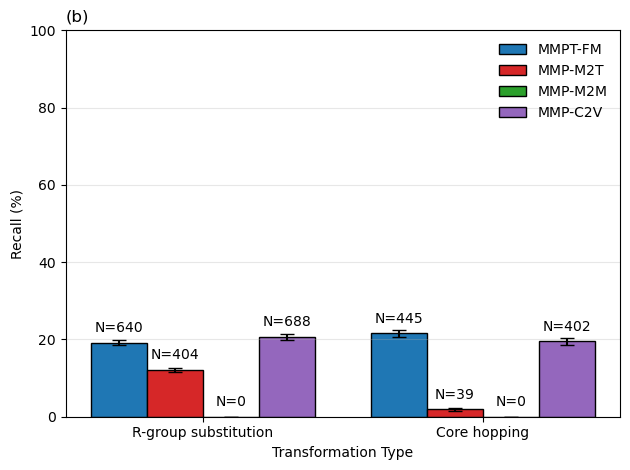

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_mmpt   = results_dict["mmpt_1000"].copy()
df_mmp_mt = results_dict["mmp_mt_1000"].copy()
df_mmp_mm = results_dict["mmp_mm_1000"].copy()
df_mmp_mc = results_dict["mmp_mc_1000"].copy()

# ----------------------------
# 1) Shared attachment-mode mapping
# ----------------------------
def add_attachment_mode(df):
    df = df.copy()
    df["attachment_mode"] = pd.NA
    df.loc[df["num_reattachment_points"] == 1, "attachment_mode"] = "R-group substitution"
    df.loc[df["num_reattachment_points"].isin([2, 3]), "attachment_mode"] = "Core hopping"
    # Keep only rows where both labels exist
    return df.dropna(subset=["attachment_mode", "rediscovered"])

df_mmpt   = add_attachment_mode(df_mmpt)
df_mmp_mt = add_attachment_mode(df_mmp_mt)
df_mmp_mm = add_attachment_mode(df_mmp_mm)
df_mmp_mc = add_attachment_mode(df_mmp_mc)

order   = ["R-group substitution", "Core hopping"]
methods = ["MMPT-FM", "MMP-M2T", "MMP-M2M", "MMP-C2V"]

# ----------------------------
# 2) Aggregate stats
# ----------------------------
def summarize(df, method_name):
    out = (
        df.groupby("attachment_mode")
          .agg(
              n=("rediscovered", "count"),
              n_success=("rediscovered", "sum"),
              rate=("rediscovered", "mean")
          )
    )
    out["rate_pct"] = out["rate"] * 100
    out["stderr"]   = np.sqrt(out["rate"] * (1 - out["rate"]) / out["n"]) * 100
    out["method"]   = method_name
    return out.reset_index()

summary = pd.concat(
    [
        summarize(df_mmpt,   "MMPT-FM"),
        summarize(df_mmp_mt, "MMP-M2T"),
        summarize(df_mmp_mm, "MMP-M2M"),
        summarize(df_mmp_mc, "MMP-C2V"),
    ],
    ignore_index=True
)

# Ensure full grid of (attachment_mode, method) exists (fill missing with 0/NaN)
idx = pd.MultiIndex.from_product([order, methods], names=["attachment_mode", "method"])
summary = (summary.set_index(["attachment_mode", "method"])
                 .reindex(idx)
                 .reset_index())

# For missing combos, set sensible defaults
summary["n"]         = summary["n"].fillna(0).astype(int)
summary["n_success"] = summary["n_success"].fillna(0).astype(int)
summary["rate_pct"]  = summary["rate_pct"].fillna(0.0)
summary["stderr"]    = summary["stderr"].fillna(0.0)

# ----------------------------
# 3) Plot grouped bars (Matplotlib) for 3 methods
# ----------------------------
x = np.arange(len(order))
width = 0.2  # narrower since 3 bars per group

fig, ax = plt.subplots()

colors = {"MMPT-FM": "C0", "MMP-M2M": "C2", "MMP-M2T": "C3", "MMP-C2V": "C4"}

for i, method in enumerate(methods):
    sub = summary[summary["method"] == method].set_index("attachment_mode").loc[order]

    # positions: centered group around x
    # i=0 -> -width, i=1 -> 0, i=2 -> +width
    xpos = x + (i - (len(methods)-1)/2) * width

    bars = ax.bar(
        xpos,
        sub["rate_pct"].values,
        width=width,
        color=colors.get(method, None),
        edgecolor="black",
        label=method,
        yerr=sub["stderr"].values,
        capsize=5,
        linewidth=1
    )

    # annotate success counts above bars
    for j, bar in enumerate(bars):
        if sub["n"].iloc[j] == 0:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f"N={int(sub['n_success'].iloc[j])}",
            ha="center",
            va="bottom",
            fontsize=10
        )

ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("Recall (%)")
ax.set_xlabel("Transformation Type")
ax.set_title("(b)", loc="left")
ax.set_ylim(0, 100)

ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figures/pmv17_pmv21_recall_by_transformation_type_mmp_vs_mmpt.pdf")
plt.show()

In [ ]:
from rdkit.Chem import AllChem, DataStructs

df_chembl = pd.read_csv("../chembl_250320_MVR33so.mmpdb.csv", sep="\t", header=None)
df_chembl.columns = ['smiles_1', 'smiles_2', 'id_1', 'id_2', 'transformation', 'context']
df_chembl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) global frequency of each transformation in ChEMBL (or whatever reference set)
value_counts = (
    df_chembl["transformation"]
    .value_counts()
    .rename("train_count")         # name the series for merge
    .reset_index()
    .rename(columns={"index": "transformation"})
)

# 2) merge counts into each subdf
results_with_counts = {}
for key, subdf in results_dict.items():
    if "1000" in key:
        sub = subdf.merge(value_counts, on="transformation", how="left")
        sub["train_count"] = sub["train_count"].fillna(0).astype(int)  # unseen -> 0
        results_with_counts[key] = sub

all_smiles = pd.unique(
    pd.concat([
        subdf[["variable_a", "variable_b"]],
    ]).values.ravel()
)

fp_dict = {
    s: AllChem.GetHashedMorganFingerprint(
        Chem.MolFromSmiles(s), 2, nBits=2048
    )
    for s in all_smiles
}

def tanimoto(fp1, fp2):
    return DataStructs.DiceSimilarity(fp1, fp2)

for key, subdf in results_with_counts.items():
    subdf["tanimoto_similarity"] = subdf.apply(
        lambda r: tanimoto(fp_dict[r["variable_a"]], fp_dict[r["variable_b"]]),
        axis=1
    )

import numpy as np
import pandas as pd

bin_edges = [-0.5, 0, 10, 100, 1000, 10000, np.inf]
bin_labels = [
    "0",
    "1-10",
    "11-100",
    "101-1000",
    "1001-10000",
    "10001+",
]

results_binned = {}

for key, sub in results_with_counts.items():
    sub = sub.copy()
    sub["count_bin"] = pd.cut(
        sub["train_count"],
        bins=bin_edges,
        labels=bin_labels,
        include_lowest=True,
    )
    results_binned[key] = sub

[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] DEPRECATION WARNING: please use MorganGenerator
[11:52:39] DEPRECATION WARNING: please use

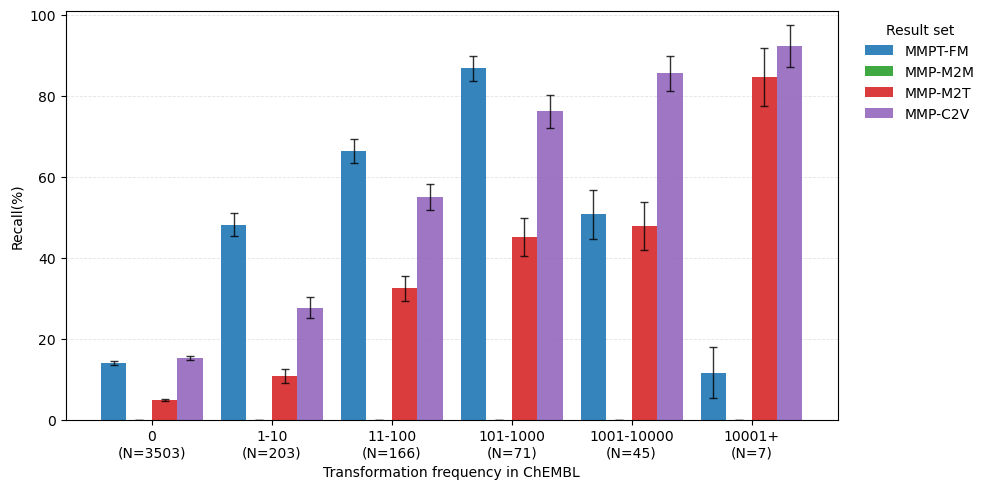

In [19]:
def summarize_rediscovery_rate(
    df,
    bin_labels,
    rediscovered_col="rediscovered",
    deduplicate=False,
):
    if rediscovered_col not in df.columns:
        raise ValueError(
            f"Column '{rediscovered_col}' not found. "
            "Use a counts-based summary instead."
        )

    data = df.copy()

    if deduplicate:
        data = data.drop_duplicates(subset=["transformation"])

    summary = (
        data.groupby("count_bin", observed=True)
        .agg(
            attempted=("transformation", "size"),
            rediscovered=(rediscovered_col, "sum"),
            n_unique_transformation=("transformation", "nunique"),  # ✅ ADD THIS
        )
        .reindex(bin_labels, fill_value=0)
    )

    p = np.where(
    summary["attempted"] > 0,
    summary["rediscovered"] / summary["attempted"],
        np.nan,
    )

    summary["rediscovery_rate"] = 100 * p

    summary["rediscovery_rate_se"] = np.where(
        summary["attempted"] > 0,
        100 * np.sqrt(p * (1 - p) / summary["attempted"]),
        np.nan,
    )

    return summary.reset_index()

summaries = {
    key: summarize_rediscovery_rate(
        df,
        bin_labels=bin_labels,
        rediscovered_col="rediscovered",
        deduplicate=False,   # set True if needed
    )
    for key, df in results_binned.items()
}

RENAME = {
    "mmpt_1000": "MMPT-FM",
    "mmp_mm_1000": "MMP-M2M",
    "mmp_mt_1000": "MMP-M2T",
    "mmp_mc_1000": "MMP-C2V",
}

import numpy as np
import matplotlib.pyplot as plt

# --- pick which series to plot (same filter as your code) ---
plot_items = [(key, summ) for key, summ in summaries.items() if "_1000" in key and "mmp" in key]

# --- x categories (keep your existing order from the summary) ---
# If you have a global bin order, prefer that; otherwise use the first summary's order.
if len(plot_items) == 0:
    raise ValueError("No keys matched '_1000'.")

x_labels = plot_items[0][1]["count_bin"].astype(str).tolist()
x = np.arange(len(x_labels))

# --- bar geometry ---
n_series = len(plot_items)
group_width = 0.85
bar_width = group_width / n_series
offsets = (np.arange(n_series) - (n_series - 1) / 2) * bar_width


fig, ax = plt.subplots(figsize=(10, 5))

MODEL_COLORS = {
    "MMPT-FM":  "C0",
    "MMP-M2M":  "C2",
    "MMP-M2T":  "C3",
    "MMP-C2V":  "C4",
}

for i, (key, summ) in enumerate(plot_items):
    # display label and color (stable even if order changes)
    label = RENAME.get(str(key), str(key))
    color = MODEL_COLORS.get(label, f"C{i}")  # fallback if not in dict

    # align this series to x_labels (important if any bins are missing)
    s = (summ.assign(count_bin_str=summ["count_bin"].astype(str))
              .set_index("count_bin_str")
              .reindex(x_labels))

    y = s["rediscovery_rate"].to_numpy(dtype=float)
    yerr = s["rediscovery_rate_se"].to_numpy(dtype=float)

    ax.bar(
        x + offsets[i],
        y,
        width=bar_width,
        label=label,
        color=color,
        align="center",
        alpha=0.9,
        yerr=yerr,
        capsize=3,
        error_kw=dict(elinewidth=1, ecolor="black", alpha=0.8),
    )

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=0)
ax.set_xlabel("Transformation frequency in ChEMBL")
ax.set_ylabel("Recall(%)")
ax.set_ylim(0, 101)

ax.legend(
    title="Result set",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

# === Compute UNIQUE transformations ONCE (same across models) ===
base = plot_items[0][1]
base_aligned = (
    base.assign(count_bin_str=base["count_bin"].astype(str))
        .set_index("count_bin_str")
        .reindex(x_labels)
)

n_unique = base_aligned["n_unique_transformation"].to_numpy(dtype=float)

ax.set_xticklabels([f"{lbl}\n(N={int(n)})" if n>0 else f"{lbl}\n(N=0)"
                    for lbl, n in zip(x_labels, n_unique)])


ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)  # grid behind bars
plt.tight_layout()
plt.savefig("figures/pmv17_pmv21_recall_by_training_frequency.pdf")

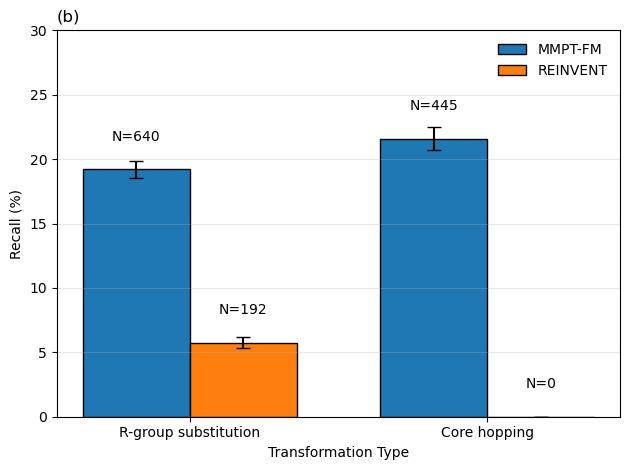

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_mmpt = results_dict["mmpt_1000"].copy()
df_reinvent = results_dict["reinvent_1000"].copy()

# ----------------------------
# 1) Shared attachment-mode mapping
# ----------------------------
def add_attachment_mode(df):
    df = df.copy()
    df["attachment_mode"] = pd.NA
    df.loc[df["num_reattachment_points"] == 1, "attachment_mode"] = "R-group substitution"
    df.loc[df["num_reattachment_points"].isin([2, 3]), "attachment_mode"] = "Core hopping"
    return df.dropna(subset=["attachment_mode", "rediscovered"])

df_mmpt = add_attachment_mode(df_mmpt)
df_reinvent = add_attachment_mode(df_reinvent)

order = ["R-group substitution", "Core hopping"]
methods = ["MMPT-FM", "REINVENT"]

# ----------------------------
# 2) Aggregate stats
# ----------------------------
def summarize(df, method_name):
    out = (
        df.groupby("attachment_mode")
          .agg(n=("rediscovered", "count"),
               n_success=("rediscovered", "sum"),
               rate=("rediscovered", "mean"))
    )
    out["rate_pct"] = out["rate"] * 100
    out["stderr"] = np.sqrt(out["rate"] * (1 - out["rate"]) / out["n"]) * 100
    out["method"] = method_name
    return out.reset_index()

summary = pd.concat(
    [summarize(df_mmpt, "MMPT-FM"), summarize(df_reinvent, "REINVENT")],
    ignore_index=True
)

# Ensure full grid of (attachment_mode, method) exists (fill missing with 0/NaN)
idx = pd.MultiIndex.from_product([order, methods], names=["attachment_mode", "method"])
summary = (summary.set_index(["attachment_mode", "method"])
                 .reindex(idx)
                 .reset_index())

# For missing combos, set sensible defaults
summary["n"] = summary["n"].fillna(0).astype(int)
summary["n_success"] = summary["n_success"].fillna(0).astype(int)
summary["rate_pct"] = summary["rate_pct"].fillna(0.0)
summary["stderr"] = summary["stderr"].fillna(0.0)

# ----------------------------
# 3) Plot grouped bars (Matplotlib)
# ----------------------------
x = np.arange(len(order))
width = 0.36

fig, ax = plt.subplots()

colors = {"MMPT-FM": "C0", "REINVENT": "C1"}  # Set2-like

for i, method in enumerate(methods):
    sub = summary[summary["method"] == method].set_index("attachment_mode").loc[order]

    # bar positions: left for MMPT-FM, right for REINVENT
    xpos = x + (i - 0.5) * width

    bars = ax.bar(
        xpos,
        sub["rate_pct"].values,
        width=width,
        color=colors[method],
        edgecolor="black",
        label=method,
        yerr=sub["stderr"].values,
        capsize=5,
        linewidth=1
    )

    # annotate success counts above bars
    for j, bar in enumerate(bars):
        # Skip annotation if there were no samples for that bar
        if sub["n"].iloc[j] == 0:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f"N={int(sub['n_success'].iloc[j])}",
            ha="center",
            va="bottom",
            fontsize=10
        )

ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("Recall (%)")
ax.set_xlabel("Transformation Type")
ax.set_title("(b)", loc="left")
ax.set_ylim(0, 30)

ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figures/pmv17_pmv21_recall_by_transformation_type.pdf")
plt.show()

In [15]:
df = samples_dict["mmpt_1000"]
df

,input_smiles,retrieval,generated_smiles,mask_infilling_smiles,invalid_mask_infilling_smiles,mcs_appearance_counts,blank_fill_records,row_index,input_smiles_canonical,generated_smiles_canonical
0,[*:1]C,{},"[C(S[*:1])c1ccccc1, C(O[*:1])c1ccccc1, Fc1cccc...",[],[],[],[],0,C[*:1],"[c1ccc(CS[*:1])cc1, c1ccc(CO[*:1])cc1, Fc1cccc..."
1,[*:1]c1cc([*:2])c([*:3])c(F)c1,{},"[Fc1ccc([*:1])c([*:3])c1[*:2], Fc1ccc([*:1])c(...",[],[],[],[],1,Fc1cc([*:1])cc([*:2])c1[*:3],"[Fc1ccc([*:1])c([*:3])c1[*:2], Fc1ccc([*:1])c(..."
2,[*:1]c1cc([*:2])c([*:3])cn1,{},"[c1cc([*:3])c([*:2])cc1[*:1], c1cc([*:2])c([*:...",[],[],[],[],2,c1c([*:1])ncc([*:3])c1[*:2],"[c1cc([*:3])c([*:2])cc1[*:1], c1cc([*:2])c([*:..."
3,[*:1]c1cc(C([*:2])([*:3])C)ccc1OC,{},"[c1cc(C([*:2])[*:3])cc([*:1])c1, COc1ccc(C([*:...",[],[],[],[],3,COc1ccc(C(C)([*:2])[*:3])cc1[*:1],"[c1cc(C([*:2])[*:3])cc([*:1])c1, COc1ccc(C([*:..."
4,[*:1]c1ccc([*:2])c([*:3])c1,{},"[c1cc([*:1])c([*:3])c([*:2])c1, c1cc([*:2])c([...",[],[],[],[],4,c1cc([*:2])c([*:3])cc1[*:1],"[c1cc([*:1])c([*:3])c([*:2])c1, c1cc([*:2])c([..."
...,...,...,...,...,...,...,...,...,...,...
308,[*:1][Si](C)(C)C,{},"[c1ccc([*:1])cc1, CC[S+]([O-])[*:1], COc1ccc([...",[],[],[],[],308,C[Si](C)(C)[*:1],"[c1ccc([*:1])cc1, CC[S+]([O-])[*:1], COc1ccc([..."
309,[*:1]S(N)(=O)=O,{},"[O=[N+]([O-])[*:1], c1ccc([*:1])cc1, NS(=O)(=O...",[],[],[],[],309,NS(=O)(=O)[*:1],"[O=[N+]([O-])[*:1], c1ccc([*:1])cc1, NS(=O)(=O..."
310,[*:1]S(=O)(=O)CC,{},"[C(S[*:1])c1ccccc1, O=[N+]([O-])[*:1], c1ccc([...",[],[],[],[],310,CCS(=O)(=O)[*:1],"[c1ccc(CS[*:1])cc1, O=[N+]([O-])[*:1], c1ccc([..."
311,[*:1]S(=O)(=O)C(F)(F)F,{},"[O=[N+]([O-])[*:1], O=S(=O)(N1CCOCC1)[*:1], CC...",[],[],[],[],311,O=S(=O)(C(F)(F)F)[*:1],"[O=[N+]([O-])[*:1], O=S(=O)(N1CCOCC1)[*:1], CC..."


In [16]:
results_dict.keys()

dict_keys(['mmpt_1000', 'mmpt_2000', 'mmpt_100', 'mmpt_500', 'reinvent_100', 'reinvent_500', 'reinvent_1000', 'reinvent_2000', 'mmp_mm_100', 'mmp_mm_500', 'mmp_mm_1000', 'mmp_mm_2000', 'mmp_mt_100', 'mmp_mt_500', 'mmp_mt_1000', 'mmp_mt_2000', 'mmp_mc_100', 'mmp_mc_500', 'mmp_mc_1000', 'mmp_mc_2000'])

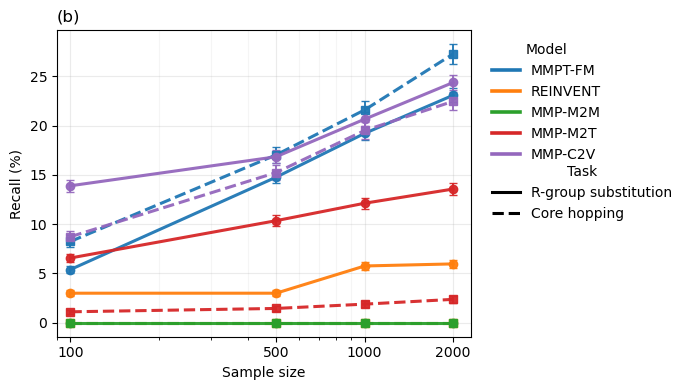

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter

beam_sizes = [100, 500, 1000, 2000]
modes = ["R-group substitution", "Core hopping"]

models = [
    {"key": "mmpt",     "label": "MMPT-FM",    "color": "C0"},
    {"key": "reinvent", "label": "REINVENT",   "color": "C1"},
    {"key": "mmp_mm",   "label": "MMP-M2M",    "color": "C2"},
    {"key": "mmp_mt",   "label": "MMP-M2T",    "color": "C3"},
    {"key": "mmp_mc",   "label": "MMP-C2V",    "color": "C4"},
]

# Storage
results = {m["key"]: {mode: [] for mode in modes} for m in models}
stderr  = {m["key"]: {mode: [] for mode in modes} for m in models}
counts  = {m["key"]: {mode: [] for mode in modes} for m in models}  # optional, but useful

for n in beam_sizes:
    for m in models:
        k = f"{m['key']}_{n}"
        if k not in results_dict:
            for mode in modes:
                results[m["key"]][mode].append(np.nan)
                stderr[m["key"]][mode].append(np.nan)
                counts[m["key"]][mode].append(0)
            continue

        df = results_dict[k]

        # R-group substitution
        sub_r = df[df["num_reattachment_points"] == 1]
        nr = len(sub_r)
        pr = sub_r["rediscovered"].mean() if nr > 0 else np.nan
        results[m["key"]]["R-group substitution"].append(pr * 100)
        stderr[m["key"]]["R-group substitution"].append(
            np.sqrt(pr * (1 - pr) / nr) * 100 if nr > 0 else np.nan
        )
        counts[m["key"]]["R-group substitution"].append(nr)

        # Core hopping
        sub_c = df[df["num_reattachment_points"] >= 2]
        nc = len(sub_c)
        pc = sub_c["rediscovered"].mean() if nc > 0 else np.nan
        results[m["key"]]["Core hopping"].append(pc * 100)
        stderr[m["key"]]["Core hopping"].append(
            np.sqrt(pc * (1 - pc) / nc) * 100 if nc > 0 else np.nan
        )
        counts[m["key"]]["Core hopping"].append(nc)

# ----------------------------
# Plot (clean + publication-ish)
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 4))

mode_style = {
    "R-group substitution": {"marker": "o", "linestyle": "-",  "alpha": 0.95},
    "Core hopping":       {"marker": "s", "linestyle": "--", "alpha": 0.95},
}

for m in models:
    key = m["key"]
    color = m["color"]

    for mode in modes:
        y = np.array(results[key][mode], dtype=float)
        e = np.array(stderr[key][mode], dtype=float)
        x = np.array(beam_sizes, dtype=float)

        # Mask missing values so caps/lines don't misbehave
        mask = np.isfinite(y) & np.isfinite(e) & np.isfinite(x)
        if not np.any(mask):
            continue

        ax.errorbar(
            x[mask],
            y[mask],
            yerr=e[mask],
            color=color,
            linewidth=2.2,
            capsize=3,
            elinewidth=1.4,
            marker=mode_style[mode]["marker"],
            markersize=6,
            linestyle=mode_style[mode]["linestyle"],
            alpha=mode_style[mode]["alpha"],
        )

# Axes/labels
ax.set_xlabel("Sample size")
ax.set_ylabel("Recall (%)")
ax.set_title("(b)", loc="left")

# Log x with fixed ticks
ax.set_xscale("log")
ax.set_xticks(beam_sizes)
ax.get_xaxis().set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.set_xlim(min(beam_sizes) * 0.9, max(beam_sizes) * 1.15)

# Cosmetic: spines + grid
ax.grid(True, which="major", axis="both", alpha=0.25)
ax.grid(True, which="minor", axis="x", alpha=0.12)  # helpful on log axis

# Two legends: models (colors) + modes (styles)
model_handles = [
    Line2D([0], [0], color=m["color"], lw=2.6, label=m["label"])
    for m in models
]
mode_handles = [
    Line2D([0], [0], color="black", lw=2.2,
           linestyle=mode_style[mode]["linestyle"],
           markersize=6, label=mode)
    for mode in modes
]

leg1 = ax.legend(handles=model_handles, title="Model", frameon=False,
                 loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.add_artist(leg1)
ax.legend(handles=mode_handles, title="Task", frameon=False,
          loc="upper left", bbox_to_anchor=(1.02, 0.60))

plt.tight_layout()
plt.savefig("figures/pmv17_pmv21_recall_by_beam_size.pdf", bbox_inches="tight")
plt.show()

[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] DEPRECATION WARNING: please use MorganGenerator
[11:52:41] DEPRECATION WARNING: please use

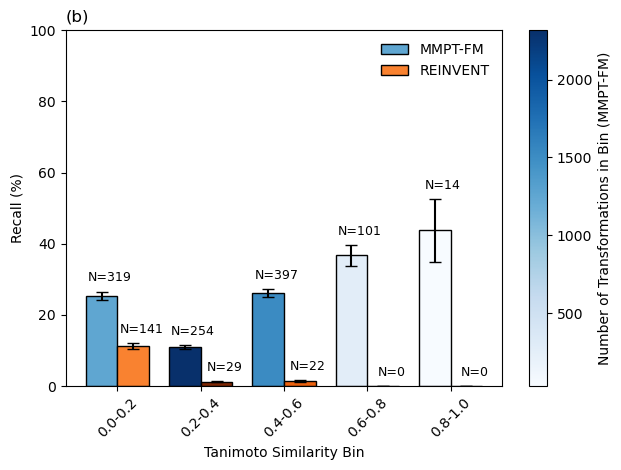

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

# ----------------------------
# Load results
# ----------------------------
df_mmpt = results_dict["mmpt_1000"].copy()
df_reinvent = results_dict["reinvent_1000"].copy()

# ----------------------------
# Precompute fingerprints (shared)
# ----------------------------
all_smiles = pd.unique(
    pd.concat([
        df_mmpt[["variable_a", "variable_b"]],
        df_reinvent[["variable_a", "variable_b"]],
    ]).values.ravel()
)

fp_dict = {
    s: AllChem.GetHashedMorganFingerprint(
        Chem.MolFromSmiles(s), 2, nBits=2048
    )
    for s in all_smiles
}

def tanimoto(fp1, fp2):
    return DataStructs.DiceSimilarity(fp1, fp2)

# ----------------------------
# Compute similarity for both
# ----------------------------
for df in (df_mmpt, df_reinvent):
    df["tanimoto_similarity"] = df.apply(
        lambda r: tanimoto(fp_dict[r["variable_a"]], fp_dict[r["variable_b"]]),
        axis=1
    )

# ----------------------------
# Bin similarity (shared bins!)
# ----------------------------
bins = np.linspace(0, 1, 6)

for df in (df_mmpt, df_reinvent):
    df["sim_bin"] = pd.cut(
        df["tanimoto_similarity"],
        bins=bins,
        include_lowest=True
    )

# ----------------------------
# Aggregate stats helper
# ----------------------------
def summarize(df):
    s = (
        df.groupby("sim_bin")
        .agg(
            n=("rediscovered", "count"),
            n_success=("rediscovered", "sum"),
            rate=("rediscovered", "mean"),
        )
    )
    s["rate_pct"] = s["rate"] * 100
    s["stderr"] = np.sqrt(s["rate"] * (1 - s["rate"]) / s["n"]) * 100
    return s

summary_mmpt = summarize(df_mmpt)
summary_reinvent = summarize(df_reinvent)

# Ensure identical bin index
summary_mmpt = summary_mmpt.reindex(summary_mmpt.index)
summary_reinvent = summary_reinvent.reindex(summary_mmpt.index)

# ----------------------------
# Plot (grouped bars)
# ----------------------------
x = np.arange(len(summary_mmpt))
width = 0.38

fig, ax = plt.subplots()

# Color by MMPT-FM sample size (same logic as your original)
norm = mcolors.Normalize(
    vmin=summary_mmpt["n"].min(),
    vmax=summary_mmpt["n"].max()
)
colors_mmpt = cm.Blues(norm(summary_mmpt["n"].fillna(0)))
colors_reinvent = cm.Oranges(norm(summary_reinvent["n"].fillna(0)))

# MMPT-FM bars
bars_mmpt = ax.bar(
    x - width / 2,
    summary_mmpt["rate_pct"],
    width,
    yerr=summary_mmpt["stderr"],
    capsize=4,
    color=colors_mmpt,
    edgecolor="black",
    label="MMPT-FM",
)

# REINVENT bars
bars_reinvent = ax.bar(
    x + width / 2,
    summary_reinvent["rate_pct"],
    width,
    yerr=summary_reinvent["stderr"],
    capsize=4,
    color=colors_reinvent,
    edgecolor="black",
    label="REINVENT",
)

# ----------------------------
# Axis / labels
# ----------------------------
ax.set_xlabel("Tanimoto Similarity Bin")
ax.set_ylabel("Recall (%)")
ax.set_title("(b)", loc="left")

ax.set_ylim(0, 100)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{abs(b.left):.1f}-{b.right:.1f}" for b in summary_mmpt.index],
    rotation=45,
    ha="center",
)

# ----------------------------
# Annotate successes
# ----------------------------
for bars, summary in [
    (bars_mmpt, summary_mmpt),
    (bars_reinvent, summary_reinvent),
]:
    for bar, (_, row) in zip(bars, summary.iterrows()):
        if not np.isnan(row["rate_pct"]):
            ax.text(
                bar.get_x() + bar.get_width() / 2 + 0.1,
                row["rate_pct"] + row["stderr"] + 2,
                f"N={int(row['n_success'])}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

# ----------------------------
# Colorbar (MMPT-FM sample size, unchanged semantics)
# ----------------------------
sm = cm.ScalarMappable(norm=norm, cmap=cm.Blues)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Number of Transformations in Bin (MMPT-FM)")

ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("figures/pmv17_pmv21_recall_by_similarity.pdf") 
plt.show()